In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
%matplotlib inline


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler




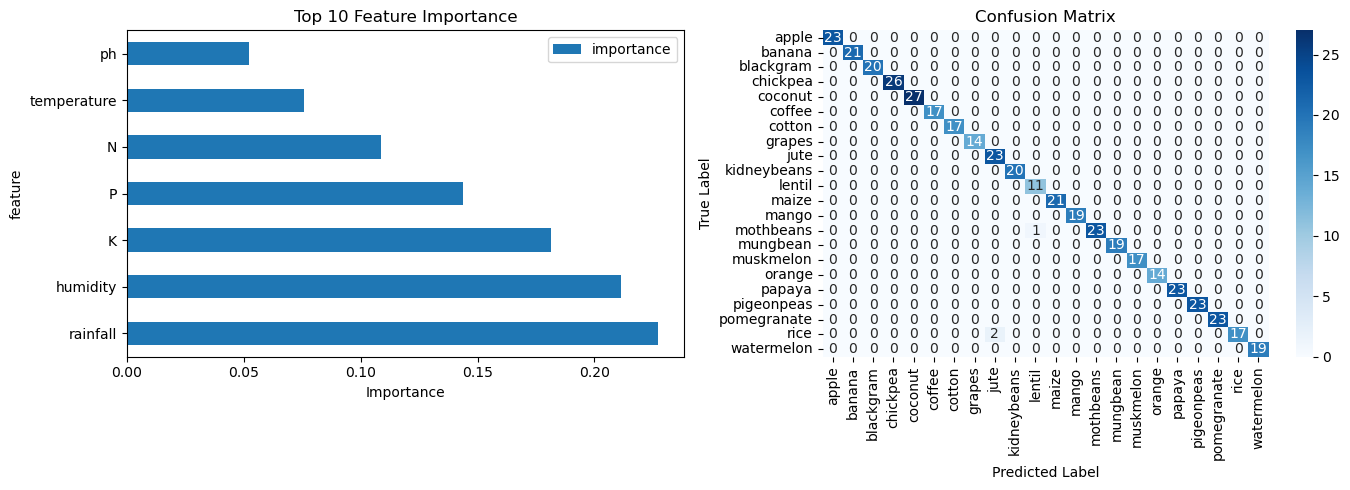


EXAMPLE PREDICTION

Farm Conditions:
N: 90, P: 42, K: 43, Temperature: 20.87°C, Humidity: 82.00%, pH: 6.50, Rainfall: 202.93mm

Predicted Crop: rice
Confidence: 99.00%


c:\Users\singh\anaconda3\envs\farm_env\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [5]:
# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Feature Importance Plot
feature_importance.head(10).plot(x='feature', y='importance', kind='barh', ax=axes[0])
axes[0].set_title('Top 10 Feature Importance')
axes[0].set_xlabel('Importance')

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1], xticklabels=model.classes_, yticklabels=model.classes_)
axes[1].set_title('Confusion Matrix')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

# Example prediction: make a prediction for new farm conditions
print("\n" + "="*50)
print("EXAMPLE PREDICTION")
print("="*50)
new_farm_data = np.array([[90, 42, 43, 20.87, 82.00, 6.50, 202.93]])
new_farm_scaled = scaler.transform(new_farm_data)
predicted_crop = model.predict(new_farm_scaled)[0]
prediction_proba = model.predict_proba(new_farm_scaled)[0]

print(f"\nFarm Conditions:")
print(f"N: 90, P: 42, K: 43, Temperature: 20.87°C, Humidity: 82.00%, pH: 6.50, Rainfall: 202.93mm")
print(f"\nPredicted Crop: {predicted_crop}")
print(f"Confidence: {max(prediction_proba):.2%}")


In [3]:
# Load and explore the dataset
df = pd.read_csv('Crop_recommendation.csv')
print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nDataset info:")
print(df.info())
print("\nCrop labels:")
print(df['label'].value_counts())

Dataset shape: (2200, 8)

First few rows:
    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), i

In [6]:
# EXPLORATORY DATA ANALYSIS (EDA)
print("\n" + "="*60)
print("EXPLORATORY DATA ANALYSIS")
print("="*60)

# Statistical Summary
print("\nStatistical Summary:")
print(df.describe())

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Numerical features correlation with each other
print("\nCorrelation Matrix:")
correlation_matrix = df.drop('label', axis=1).corr()
print(correlation_matrix)

# Distribution of crops
print(f"\nTotal unique crops: {df['label'].nunique()}")
print(f"Samples per crop: {df['label'].value_counts().iloc[0]}")



EXPLORATORY DATA ANALYSIS

Statistical Summary:
                 N            P            K  temperature     humidity  \
count  2200.000000  2200.000000  2200.000000  2200.000000  2200.000000   
mean     50.551818    53.362727    48.149091    25.616244    71.481779   
std      36.917334    32.985883    50.647931     5.063749    22.263812   
min       0.000000     5.000000     5.000000     8.825675    14.258040   
25%      21.000000    28.000000    20.000000    22.769375    60.261953   
50%      37.000000    51.000000    32.000000    25.598693    80.473146   
75%      84.250000    68.000000    49.000000    28.561654    89.948771   
max     140.000000   145.000000   205.000000    43.675493    99.981876   

                ph     rainfall  
count  2200.000000  2200.000000  
mean      6.469480   103.463655  
std       0.773938    54.958389  
min       3.504752    20.211267  
25%       5.971693    64.551686  
50%       6.425045    94.867624  
75%       6.923643   124.267508  
max       9.

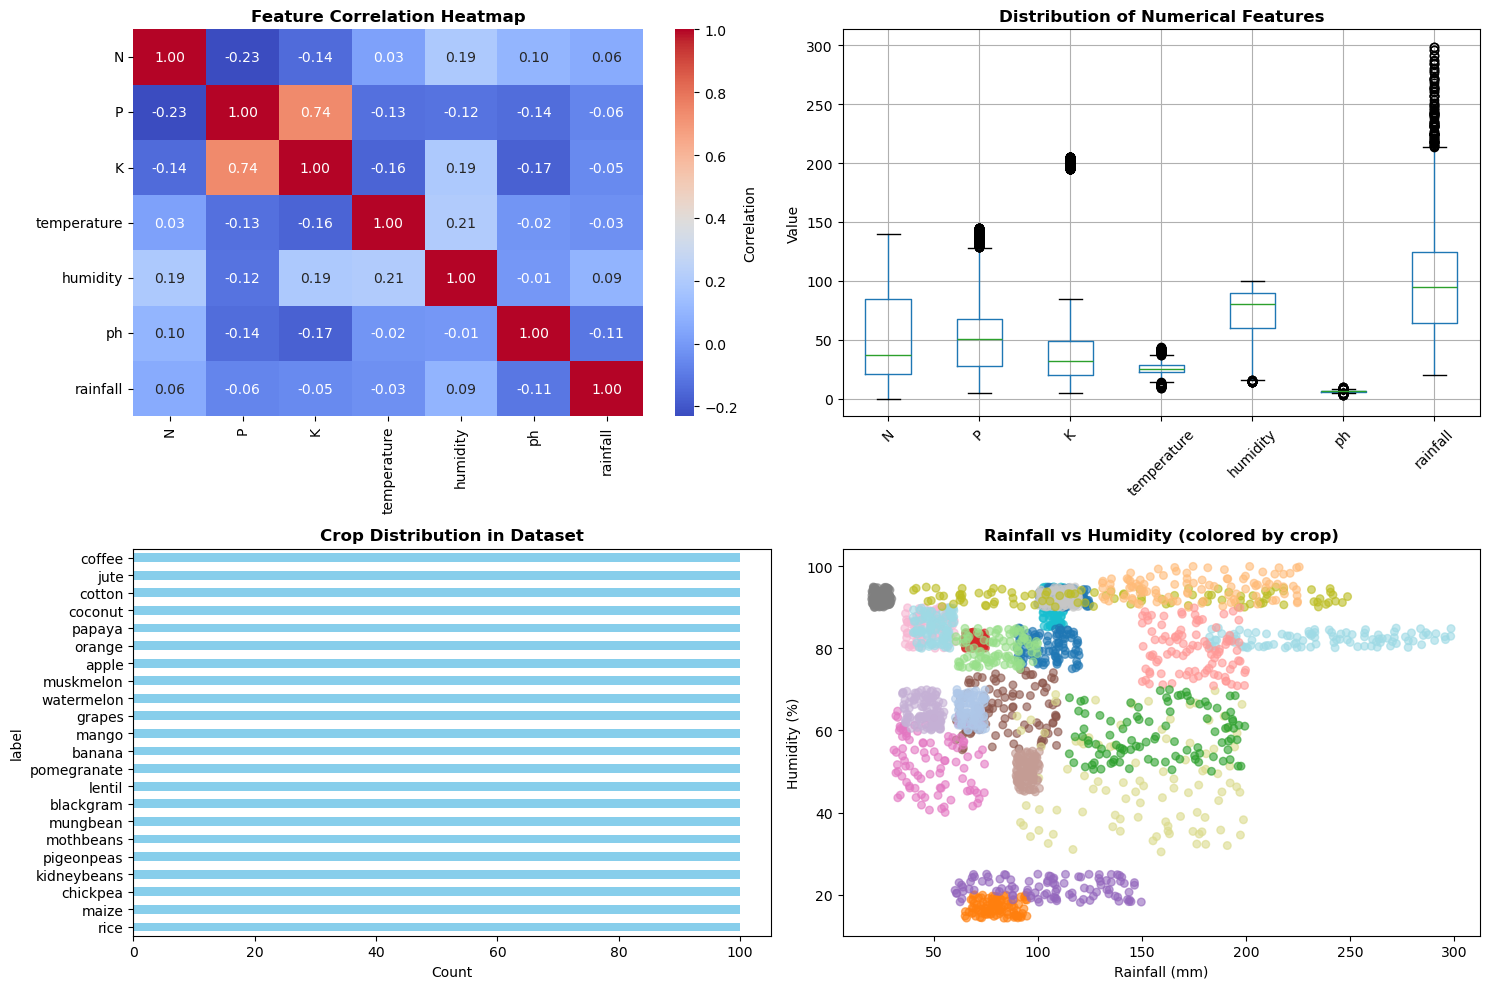


EDA visualization complete!


In [7]:
# EDA Visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Correlation heatmap
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[0, 0], cbar_kws={'label': 'Correlation'})
axes[0, 0].set_title('Feature Correlation Heatmap', fontsize=12, fontweight='bold')

# 2. Distribution of numerical features
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
df[features].boxplot(ax=axes[0, 1])
axes[0, 1].set_title('Distribution of Numerical Features', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Value')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Top crops in dataset
top_crops = df['label'].value_counts()
top_crops.plot(kind='barh', ax=axes[1, 0], color='skyblue')
axes[1, 0].set_title('Crop Distribution in Dataset', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Count')

# 4. Rainfall vs Humidity (scatter plot colored by top crops)
scatter = axes[1, 1].scatter(df['rainfall'], df['humidity'], c=df['label'].astype('category').cat.codes, cmap='tab20', alpha=0.6, s=30)
axes[1, 1].set_xlabel('Rainfall (mm)')
axes[1, 1].set_ylabel('Humidity (%)')
axes[1, 1].set_title('Rainfall vs Humidity (colored by crop)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nEDA visualization complete!")


In [8]:
# Feature ranges and crop-specific insights
print("\n" + "="*60)
print("FEATURE RANGES & CROP INSIGHTS")
print("="*60)

print("\nFeature Ranges:")
for feature in features:
    print(f"{feature:15s}: Min={df[feature].min():8.2f}, Max={df[feature].max():8.2f}, Mean={df[feature].mean():8.2f}")

# Crop-specific statistics (sample crops)
print("\n\nSample Crop Requirements:")
sample_crops = ['rice', 'maize', 'cotton', 'apple', 'coffee']
for crop in sample_crops:
    crop_data = df[df['label'] == crop][features].mean()
    print(f"\n{crop.upper()}:")
    for feat in features:
        print(f"  {feat:15s}: {crop_data[feat]:8.2f}")



FEATURE RANGES & CROP INSIGHTS

Feature Ranges:
N              : Min=    0.00, Max=  140.00, Mean=   50.55
P              : Min=    5.00, Max=  145.00, Mean=   53.36
K              : Min=    5.00, Max=  205.00, Mean=   48.15
temperature    : Min=    8.83, Max=   43.68, Mean=   25.62
humidity       : Min=   14.26, Max=   99.98, Mean=   71.48
ph             : Min=    3.50, Max=    9.94, Mean=    6.47
rainfall       : Min=   20.21, Max=  298.56, Mean=  103.46


Sample Crop Requirements:

RICE:
  N              :    79.89
  P              :    47.58
  K              :    39.87
  temperature    :    23.69
  humidity       :    82.27
  ph             :     6.43
  rainfall       :   236.18

MAIZE:
  N              :    77.76
  P              :    48.44
  K              :    19.79
  temperature    :    22.39
  humidity       :    65.09
  ph             :     6.25
  rainfall       :    84.77

COTTON:
  N              :   117.77
  P              :    46.24
  K              :    19.56
  temperat

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

# Prepare features and target
X = df.drop('label', axis=1)
y = df['label']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Random Forest classifier
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = model.predict(X_test_scaled)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop Feature Importance:")
print(feature_importance)

Model Accuracy: 0.9932

Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       1.00      1.00      1.00        17
      cotton       1.00      1.00      1.00        17
      grapes       1.00      1.00      1.00        14
        jute       0.92      1.00      0.96        23
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.92      1.00      0.96        11
       maize       1.00      1.00      1.00        21
       mango       1.00      1.00      1.00        19
   mothbeans       1.00      0.96      0.98        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00      1.00      1.00        17
      orange       1.00      1.00 

In [9]:
import pickle
import os

# Create models directory if it doesn't exist
os.makedirs('models', exist_ok=True)

# Save the trained model
with open('models/crop_model.pkl', 'wb') as f:
    pickle.dump(model, f)

# Save the scaler
with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("✓ Model saved to models/crop_model.pkl")
print("✓ Scaler saved to models/scaler.pkl")
print("✓ Ready for Flask app deployment!")


✓ Model saved to models/crop_model.pkl
✓ Scaler saved to models/scaler.pkl
✓ Ready for Flask app deployment!
